# 04 — Information Lagrangian

**Manuscript:** Part IV §7.

$\mathcal{I} = \sum_{i,j} w_{ij} I(i:j)$; $L_{\mathrm{info}} = \sum_{i,j} J_{ij} I(i:j) - \lambda \sum_i S_i$; extremize $\delta S_{\mathrm{info}}=0$.

In [1]:
import os, sys
cwd = os.getcwd()
root = os.path.dirname(cwd) if os.path.basename(cwd) == 'notebooks' else cwd
if root not in sys.path:
    sys.path.insert(0, root)
import numpy as np
from src.entanglement_geometry import (
    information_action,
    information_lagrangian_value,
    from_qiskit_statevector,
)
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Toy: 4-qubit state (e.g. two Bell pairs)
qc = QuantumCircuit(4)
qc.h(0)
qc.cx(0, 1)
qc.h(2)
qc.cx(2, 3)
sv = Statevector.from_instruction(qc)

# Compute I(i:j) for pairs (0,1), (0,2), (1,2), (2,3), etc.
def pair_mutual_info(sv, i, j):
    (S_A, S_B, S_AB, I_AB, _), _ = from_qiskit_statevector(sv, [i], [j])
    return I_AB

I_ij = {}
for i in range(4):
    for j in range(i+1, 4):
        I_ij[(i, j)] = pair_mutual_info(sv, i, j)

print('Mutual information I(i:j) (nats):')
for (i, j), val in I_ij.items():
    print(f'  I({i}:{j}) = {val:.4f}')

Mutual information I(i:j) (nats):
  I(0:1) = 1.3863
  I(0:2) = 0.0000
  I(0:3) = 0.0000
  I(1:2) = 0.0000
  I(1:3) = 0.0000
  I(2:3) = 1.3863


In [2]:
# Information action I = sum w_ij I(i:j)
I_total = information_action(I_ij)
print(f'Information action I = {I_total:.4f}')

# L_info with J_ij=1, lambda=0.1; need S_i (single-site entropies)
S_i = {}
for i in range(4):
    (S_A, _, _, _, _), _ = from_qiskit_statevector(sv, [i], [])
    S_i[i] = S_A
L_info = information_lagrangian_value(I_ij, S_i, lam=0.1)
print(f'L_info (lam=0.1) = {L_info:.4f}')

Information action I = 2.7726
L_info (lam=0.1) = 2.4953


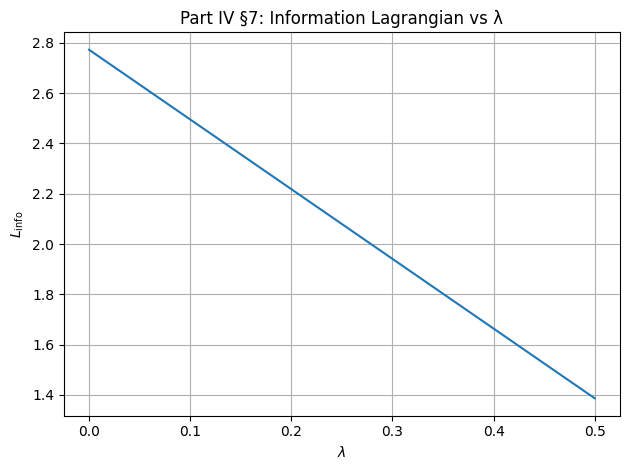

In [3]:
# Simple extremization: vary a parameter in a toy Hamiltonian and compute L_info (conceptual)
# Here we just show L_info as function of lambda
lams = np.linspace(0, 0.5, 20)
L_vals = [information_lagrangian_value(I_ij, S_i, lam=lam) for lam in lams]

import matplotlib.pyplot as plt
plt.plot(lams, L_vals)
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$L_{\mathrm{info}}$')
plt.title('Part IV §7: Information Lagrangian vs λ')
plt.grid(True)
plt.tight_layout()
plt.show()